# Ứng dụng 2 - Dự đoán giá nhà

**Mục tiêu:** dự đoán giá niêm yết của một căn nhà theo đơn vị PLN từ đặc điểm vật lý, thị trường và vị trí.

## 1. Chuẩn bị môi trường và thư viện

Phần này khai báo các công cụ dùng cho tiền xử lý dữ liệu bảng, hồi quy, đánh giá, trực quan hóa và lưu mô hình.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

BASE_DIR = Path(r"D:\Assignment2")
DATA_DIR = BASE_DIR / "data" / "house"
MODEL_DIR = BASE_DIR / "models"

## 2. Đọc dữ liệu và xác định bài toán

Mỗi quan sát đại diện cho một tin đăng bất động sản tại Ba Lan. Nhãn `price` là giá trị liên tục nên đây là bài toán hồi quy.

In [2]:
DATA_PATH = DATA_DIR / "house.csv"

df = pd.read_csv(DATA_PATH)


# =========================
# Chuẩn hóa tên cột
# =========================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(
        r"\s+",
        "_",
        regex=True
    )
)


# =========================
# Fix mojibake Polish city names
# Ví dụ:
# KrakĂłw  -> Kraków
# WrocĹ‚aw -> Wrocław
# GdaĹ„sk  -> Gdańsk
# =========================

POLISH_ENCODING_FIXES = {
    "Ä…": "ą",
    "Ä‡": "ć",
    "Ä™": "ę",
    "Ĺ‚": "ł",
    "Ĺ„": "ń",
    "Ăł": "ó",
    "Ĺ›": "ś",
    "Ĺş": "ź",
    "ĹĽ": "ż",

    "Ä„": "Ą",
    "Ä†": "Ć",
    "Ă“": "Ó",
    "Ĺš": "Ś",
    "Ĺą": "Ź",
    "Ĺ»": "Ż",

    "Ĺ\u0081": "Ł",
    "Ä\u0098": "Ę",
    "Ĺ\u0083": "Ń"
}


if "city_name" in df.columns:

    city_fixed = (
        df["city_name"]
        .astype(str)
    )

    for bad, good in (
        POLISH_ENCODING_FIXES.items()
    ):

        city_fixed = (
            city_fixed
            .str.replace(
                bad,
                good,
                regex=False
            )
        )

    df["city_name"] = city_fixed


print(
    "Dataset path:",
    DATA_PATH
)

print(
    "Dataset shape:",
    df.shape
)

print(
    "\nTop cities after encoding fix:"
)

print(
    df["city_name"]
    .value_counts()
    .head(10)
)


display(
    df.head()
)

Dataset path: D:\Assignment2\data\house\house.csv
Dataset shape: (62818, 16)

Top cities after encoding fix:
city_name
Warszawa     4297
Kraków       3446
Łódź         3161
Wrocław      2350
Szczecin     1448
Lublin       1389
Poznań       1161
Bydgoszcz    1045
Katowice      915
Gdańsk        842
Name: count, dtype: int64


,offer_title,price,price_per_meter,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,year,population,longitude,latitude
0,Kawalerka na sprzedaĹĽ,240000.0,8888.89,Private,1.0,27.00,1,Housing Block,primary,Bolesławiec,Lower Silesia,January,2022,39603,15.565105,51.263033
1,Nowoczesna kawalerka z winda plus garaĹĽ podzi...,250000.0,7142.86,Private,1.0,35.00,1,Housing Block,primary,Jelcz-Laskowice,Lower Silesia,January,2022,15828,17.349964,51.039831
2,Nowa kawalerka z Balkonem/Legnicka/Magnolia,259000.0,10360.00,Estate Agency,2.0,25.00,1,Housing Block,primary,Wrocław,Lower Silesia,January,2022,634487,17.032669,51.108978
3,Kawalerka z balkonem/klucze I kwartaĹ‚ 2022/60...,269000.0,10275.02,Private,3.0,26.18,1,Apartment Building,primary,Wrocław,Lower Silesia,January,2022,634487,17.032669,51.108978
4,40 tys. taniej od dewelopera/Kawalerka/Magnoli...,258000.0,9923.08,Estate Agency,3.0,26.00,1,Housing Block,primary,Wrocław,Lower Silesia,January,2022,634487,17.032669,51.108978


In [3]:
dataset_info = pd.DataFrame({
    "Item": [
        "Dataset",
        "Source",
        "Kaggle URL",
        "Rows",
        "Columns",
        "Target",
        "Problem Type",
        "One Observation"
    ],
    "Value": [
        "Poland OLX House Price Q1 2022",
        "Kaggle",
        "https://www.kaggle.com/datasets/g1llar/poland-olx-house-price-q122",
        df.shape[0],
        df.shape[1],
        "price",
        "Regression",
        "One real-estate listing"
    ]
})

display(dataset_info)

,Item,Value
0,Dataset,Poland OLX House Price Q1 2022
1,Source,Kaggle
2,Kaggle URL,https://www.kaggle.com/datasets/g1llar/poland-...
3,Rows,62818
4,Columns,16
5,Target,price
6,Problem Type,Regression
7,One Observation,One real-estate listing


## 3. Khảo sát và tìm hiểu dữ liệu

Dữ liệu gốc được kiểm tra thông qua kích thước, tên cột, kiểu dữ liệu, các bản ghi mẫu và thống kê mô tả trước khi làm sạch.

In [4]:
print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nDataFrame information:")
df.info()

Number of rows   : 62818
Number of columns: 16

Columns:
['offer_title', 'price', 'price_per_meter', 'offer_type', 'floor', 'area', 'rooms', 'offer_type_of_building', 'market', 'city_name', 'voivodeship', 'month', 'year', 'population', 'longitude', 'latitude']

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62818 entries, 0 to 62817
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   offer_title             62818 non-null  object 
 1   price                   62818 non-null  float64
 2   price_per_meter         62818 non-null  float64
 3   offer_type              62818 non-null  object 
 4   floor                   61331 non-null  float64
 5   area                    61331 non-null  float64
 6   rooms                   62818 non-null  int64  
 7   offer_type_of_building  61331 non-null  object 
 8   market                  62818 non-null  object 
 9   city_name         

In [5]:
display(
    df.describe(
        include="all"
    ).T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
offer_title,62818,29138,Sprzedam mieszkanie,1855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,62818.0,NaN,NaN,NaN,399405.854865,2023250.514224,1.0,260000.0,345000.0,460000.0,504151616.0
price_per_meter,62818.0,NaN,NaN,NaN,7596.442371,36561.779747,0.02,5250.0,6576.845,8766.93,9002707.43
offer_type,62818,2,Private,45449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor,61331.0,NaN,NaN,NaN,2.399749,2.15051,-1.0,1.0,2.0,3.0,11.0
area,61331.0,NaN,NaN,NaN,91.251837,3153.663628,1.0,42.0,51.2,63.0,399000.0
rooms,62818.0,NaN,NaN,NaN,2.515378,0.826473,1.0,2.0,2.0,3.0,4.0
offer_type_of_building,61331,5,Housing Block,43868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market,62818,2,aftermarket,55171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_name,62818,611,Warszawa,4297,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Đánh giá chất lượng dữ liệu

Phần này kiểm tra giá trị thiếu, tin đăng trùng lặp, tính hợp lệ của giá, sự nhất quán của biến phân loại và các khoảng số bất thường.

In [6]:
print("===== MISSING VALUES =====")

missing_table = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": df.isna().mean() * 100
})

display(
    missing_table
    .sort_values(
        "Missing_Percent",
        ascending=False
    )
    .round(2)
)


print(
    "\nTotal missing:",
    df.isna().sum().sum()
)


print("\n===== DUPLICATES =====")

duplicate_count = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_count
)

print(
    "Duplicate percentage:",
    round(
        duplicate_count / len(df) * 100,
        2
    ),
    "%"
)

===== MISSING VALUES =====


,Missing_Count,Missing_Percent
area,1487,2.37
offer_type_of_building,1487,2.37
floor,1487,2.37
offer_title,0,0.00
offer_type,0,0.00
price_per_meter,0,0.00
price,0,0.00
rooms,0,0.00
market,0,0.00
city_name,0,0.00



Total missing: 4461

===== DUPLICATES =====
Duplicate rows: 10482
Duplicate percentage: 16.69 %


In [7]:
TARGET = "price"

if TARGET not in df.columns:
    raise ValueError(
        f"Target '{TARGET}' not found in dataset."
    )

print("Target:", TARGET)

print("\n===== PRICE STATISTICS =====")

display(
    df[TARGET]
    .describe()
)

Target: price

===== PRICE STATISTICS =====


count    6.281800e+04
mean     3.994059e+05
std      2.023251e+06
min      1.000000e+00
25%      2.600000e+05
50%      3.450000e+05
75%      4.600000e+05
max      5.041516e+08
Name: price, dtype: float64

In [8]:
categorical_raw = (
    df.select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()
)

print("Categorical columns:")

print(categorical_raw)


for col in categorical_raw:

    print(
        f"\n===== {col} ====="
    )

    print(
        df[col]
        .value_counts(
            dropna=False
        )
        .head(10)
    )

Categorical columns:
['offer_title', 'offer_type', 'offer_type_of_building', 'market', 'city_name', 'voivodeship', 'month']

===== offer_title =====
offer_title
Sprzedam mieszkanie        1855
Mieszkanie na sprzedaĹĽ     748
Sprzedam Mieszkanie         191
Mieszkanie 3 pokojowe       146
sprzedam mieszkanie         144
Mieszkanie sprzedam          83
Mieszkanie 2 pokojowe        80
Sprzedam mieszkanie.         66
Sprzedam kawalerkÄ™          66
Mieszkanie na sprzedaz       55
Name: count, dtype: int64

===== offer_type =====
offer_type
Private          45449
Estate Agency    17369
Name: count, dtype: int64

===== offer_type_of_building =====
offer_type_of_building
Housing Block         43868
Tenement               8735
Apartment Building     6373
Other                  2251
NaN                    1487
Loft                    104
Name: count, dtype: int64

===== market =====
market
aftermarket    55171
primary         7647
Name: count, dtype: int64

===== city_name =====
city_name
Warsz

In [9]:
quality_checks = []


if "price" in df.columns:

    quality_checks.append({
        "Check": "price <= 0",
        "Count": (
            df["price"] <= 0
        ).sum()
    })


if "area" in df.columns:

    quality_checks.append({
        "Check": "area <= 0",
        "Count": (
            df["area"] <= 0
        ).sum()
    })


if "rooms" in df.columns:

    quality_checks.append({
        "Check": "rooms <= 0",
        "Count": (
            df["rooms"] <= 0
        ).sum()
    })


display(
    pd.DataFrame(
        quality_checks
    )
)

,Check,Count
0,price <= 0,0
1,area <= 0,0
2,rooms <= 0,0


## 5. Kiểm tra leakage và đặc trưng không phù hợp

`price_per_meter` được tính từ giá và diện tích nên nếu dùng làm đầu vào sẽ gây target leakage. Văn bản tin đăng có số lượng giá trị quá lớn và các cột định danh cũng không được đưa vào mô hình bảng.

In [10]:
leakage_candidates = [
    "price_per_meter",
    "price_per_m2",
    "price_per_sqm",
    "price_m2"
]

irrelevant_candidates = [
    "id",
    "offer_id",
    "url",
    "link",
    "offer_title",
    "title",
    "description",
    "created_at",
    "scraped_at"
]


leakage_columns = [
    col
    for col in leakage_candidates
    if col in df.columns
]


irrelevant_columns = [
    col
    for col in irrelevant_candidates
    if col in df.columns
]


print(
    "Target leakage columns:",
    leakage_columns
)

print(
    "Irrelevant / high-cardinality columns:",
    irrelevant_columns
)

Target leakage columns: ['price_per_meter']
Irrelevant / high-cardinality columns: ['offer_title']


In [11]:
outlier_features = [
    col
    for col in [
        "price",
        "area",
        "population"
    ]
    if col in df.columns
]


outlier_results = []


for col in outlier_features:

    values = (
        df[col]
        .dropna()
    )

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = (
        (values < lower)
        |
        (values > upper)
    ).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count
    })


outlier_table = pd.DataFrame(
    outlier_results
)

display(outlier_table)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,price,260000.0,460000.0,200000.0,-40000.0,760000.0,3030
1,area,42.0,63.0,21.0,10.5,94.5,2562
2,population,33967.0,402465.0,368498.0,-518780.0,955212.0,4297


In [12]:
print(
    "===== EXTREME / INVALID VALUE CHECK ====="
)


# =========================
# PRICE
# =========================

print("\n===== PRICE =====")

print(
    "Price < 10,000 PLN:",
    (
        df["price"]
        < 10_000
    ).sum()
)

print(
    "Price > 10,000,000 PLN:",
    (
        df["price"]
        > 10_000_000
    ).sum()
)


# =========================
# AREA
# =========================

print("\n===== AREA =====")

print(
    "Area < 10 m²:",
    (
        df["area"].notna()
        &
        (
            df["area"]
            < 10
        )
    ).sum()
)

print(
    "Area > 500 m²:",
    (
        df["area"].notna()
        &
        (
            df["area"]
            > 500
        )
    ).sum()
)


# =========================
# PRICE PER METER
# chỉ dùng để kiểm tra chất lượng
# KHÔNG đưa vào model
# =========================

print(
    "\n===== PRICE PER METER ====="
)

print(
    "Price/m² > 100,000 PLN:",
    (
        df[
            "price_per_meter"
        ]
        > 100_000
    ).sum()
)


# =========================
# LOWEST PRICE RECORDS
# =========================

print(
    "\n===== LOWEST PRICES ====="
)

display(
    df[
        [
            "price",
            "area",
            "rooms",
            "city_name",
            "price_per_meter"
        ]
    ]
    .sort_values(
        "price"
    )
    .head(10)
)


# =========================
# HIGHEST PRICE/M² RECORDS
# =========================

print(
    "\n===== HIGHEST PRICE PER M² ====="
)

display(
    df[
        [
            "price",
            "area",
            "rooms",
            "city_name",
            "price_per_meter"
        ]
    ]
    .sort_values(
        "price_per_meter",
        ascending=False
    )
    .head(10)
)

===== EXTREME / INVALID VALUE CHECK =====

===== PRICE =====
Price < 10,000 PLN: 103
Price > 10,000,000 PLN: 1

===== AREA =====
Area < 10 m²: 51
Area > 500 m²: 75

===== PRICE PER METER =====
Price/m² > 100,000 PLN: 33

===== LOWEST PRICES =====


,price,area,rooms,city_name,price_per_meter
30367,1.0,45.00,2,Warka,0.02
40349,4.0,62.00,4,Siedlce,0.06
40934,100.0,10.00,1,Wrocław,10.00
405,100.0,50.00,2,Zabrze,2.00
19507,100.0,10.00,1,Wrocław,10.00
31485,120.0,23.30,1,Puławy,5.15
2057,123.0,45.00,2,Lądek-Zdrój,2.73
4608,149.0,37.00,2,Zabrze,4.03
24886,159.0,36.38,2,Bartoszyce,4.37
40441,246.0,140.00,4,Kędzierzyn-Koźle,1.76



===== HIGHEST PRICE PER M² =====


,price,area,rooms,city_name,price_per_meter
36254,504151616.0,56.0,2,Szczecin,9002707.43
13353,429000.0,1.0,2,Żyrardów,429000.00
56461,425000.0,NaN,2,Jarosław,425000.00
45580,425000.0,NaN,2,Jarosław,425000.00
38296,389000.0,1.0,3,Żyrardów,389000.00
25089,300000.0,NaN,2,Kalisz,300000.00
14616,300000.0,NaN,2,Kalisz,300000.00
57736,300000.0,NaN,2,Kalisz,300000.00
35855,300000.0,NaN,2,Kalisz,300000.00
23776,299000.0,1.0,2,Żyrardów,299000.00


## 6. Làm sạch dữ liệu

Các quy tắc miền cố định được dùng để loại dòng trùng và các giá trị giá, diện tích, giá trên mét vuông rõ ràng không hợp lệ. `price_per_meter` chỉ dùng để kiểm tra chất lượng rồi bị loại trước khi huấn luyện.

In [13]:
df_clean = df.copy()


# =========================
# Cleaning thresholds
# =========================

PRICE_MIN = 10_000
PRICE_MAX = 10_000_000

AREA_MIN = 10
AREA_MAX = 500

PRICE_PER_METER_MAX = 100_000


# =========================
# 1. Exact duplicates
# =========================

rows_before = len(
    df_clean
)

df_clean = (
    df_clean
    .drop_duplicates()
    .copy()
)

duplicates_removed = (
    rows_before
    - len(df_clean)
)


# =========================
# 2. Missing target
# =========================

rows_before = len(
    df_clean
)

df_clean = (
    df_clean[
        df_clean[
            TARGET
        ].notna()
    ]
    .copy()
)

missing_target_removed = (
    rows_before
    - len(df_clean)
)


# =========================
# 3. Invalid/extreme price
# =========================

rows_before = len(
    df_clean
)

df_clean = (
    df_clean[
        df_clean[
            TARGET
        ].between(
            PRICE_MIN,
            PRICE_MAX
        )
    ]
    .copy()
)

price_removed = (
    rows_before
    - len(df_clean)
)


# =========================
# 4. Invalid/extreme area
# Missing area được giữ lại
# để pipeline impute từ TRAIN
# =========================

area_removed = 0

if "area" in df_clean.columns:

    rows_before = len(
        df_clean
    )

    df_clean = (
        df_clean[
            df_clean[
                "area"
            ].isna()
            |
            df_clean[
                "area"
            ].between(
                AREA_MIN,
                AREA_MAX
            )
        ]
        .copy()
    )

    area_removed = (
        rows_before
        - len(df_clean)
    )


# =========================
# 5. Suspicious price/m²
# Chỉ dùng để sanity check.
# Sau đó vẫn DROP khỏi model.
# =========================

price_per_meter_removed = 0

if (
    "price_per_meter"
    in df_clean.columns
):

    rows_before = len(
        df_clean
    )

    df_clean = (
        df_clean[
            df_clean[
                "price_per_meter"
            ].notna()
            &
            (
                df_clean[
                    "price_per_meter"
                ]
                <=
                PRICE_PER_METER_MAX
            )
        ]
        .copy()
    )

    price_per_meter_removed = (
        rows_before
        - len(df_clean)
    )


# =========================
# RESULTS
# =========================

print(
    "Original rows:",
    len(df)
)

print(
    "Clean rows   :",
    len(df_clean)
)

print(
    "Rows removed :",
    len(df)
    - len(df_clean)
)


print(
    "\nDuplicates removed:",
    duplicates_removed
)

print(
    "Missing target removed:",
    missing_target_removed
)

print(
    "Invalid price removed:",
    price_removed
)

print(
    "Invalid/extreme area removed:",
    area_removed
)

print(
    "Extreme price/m² removed:",
    price_per_meter_removed
)


print(
    "\nFinal price range:",
    df_clean[
        TARGET
    ].min(),
    "→",
    df_clean[
        TARGET
    ].max()
)


print(
    "Final area range:",
    df_clean[
        "area"
    ].min(),
    "→",
    df_clean[
        "area"
    ].max()
)


print(
    "Final max price/m²:",
    df_clean[
        "price_per_meter"
    ].max()
)


print(
    "Duplicates remaining:",
    df_clean
    .duplicated()
    .sum()
)

Original rows: 62818
Clean rows   : 52146
Rows removed : 10672

Duplicates removed: 10482
Missing target removed: 0
Invalid price removed: 94
Invalid/extreme area removed: 91
Extreme price/m² removed: 5

Final price range: 10000.0 → 6000000.0
Final area range: 11.0 → 450.0
Final max price/m²: 60000.0
Duplicates remaining: 0


In [14]:
cleaning_summary = pd.DataFrame({

    "Cleaning Step": [

        "Original rows",

        "Exact duplicates removed",

        "Missing target removed",

        "Invalid/extreme price removed",

        "Invalid/extreme area removed",

        "Extreme price/m² removed",

        "Final clean rows"
    ],

    "Count": [

        len(df),

        duplicates_removed,

        missing_target_removed,

        price_removed,

        area_removed,

        price_per_meter_removed,

        len(df_clean)
    ]
})


display(
    cleaning_summary
)


print(
    "Final price min:",
    df_clean[
        TARGET
    ].min()
)

print(
    "Final price median:",
    df_clean[
        TARGET
    ].median()
)

print(
    "Final price max:",
    df_clean[
        TARGET
    ].max()
)


print(
    "\nFinal area min:",
    df_clean[
        "area"
    ].min()
)

print(
    "Final area max:",
    df_clean[
        "area"
    ].max()
)


print(
    "\nFinal max price/m²:",
    df_clean[
        "price_per_meter"
    ].max()
)

,Cleaning Step,Count
0,Original rows,62818
1,Exact duplicates removed,10482
2,Missing target removed,0
3,Invalid/extreme price removed,94
4,Invalid/extreme area removed,91
5,Extreme price/m² removed,5
6,Final clean rows,52146


Final price min: 10000.0
Final price median: 345000.0
Final price max: 6000000.0

Final area min: 11.0
Final area max: 450.0

Final max price/m²: 60000.0


## 7. Xác định đặc trưng và biểu diễn dữ liệu

Các cột hằng số, gây leakage hoặc không phù hợp được loại bỏ. Các thuộc tính số và phân loại còn lại tạo thành ma trận `X`, còn `price` tạo thành vector mục tiêu `y`.

In [15]:
# =========================
# Constant / zero-variance columns
# =========================

constant_columns = [

    col

    for col in df_clean.columns

    if (
        col != TARGET

        and

        df_clean[
            col
        ]
        .nunique(
            dropna=True
        )
        <= 1
    )
]


print(
    "Constant / zero-variance columns:",
    constant_columns
)


# =========================
# Columns excluded from model
# =========================

drop_columns = list(
    dict.fromkeys(

        leakage_columns

        + irrelevant_columns

        + constant_columns
    )
)


# =========================
# X / y
# =========================

X = (
    df_clean

    .drop(
        columns=[
            TARGET
        ]
        + drop_columns,

        errors="ignore"
    )

    .copy()
)


y = (
    df_clean[
        TARGET
    ]
    .astype(float)
)


print(
    "\nX shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)


print(
    "\nDropped columns:"
)

print(
    drop_columns
)


print(
    "\nInput columns:"
)

print(
    X.columns.tolist()
)

Constant / zero-variance columns: ['year']

X shape: (52146, 12)
y shape: (52146,)

Dropped columns:
['price_per_meter', 'offer_title', 'year']

Input columns:
['offer_type', 'floor', 'area', 'rooms', 'offer_type_of_building', 'market', 'city_name', 'voivodeship', 'month', 'population', 'longitude', 'latitude']


In [16]:
numerical_features = (
    X
    .select_dtypes(
        include=[
            "number"
        ]
    )
    .columns
    .tolist()
)


categorical_features = (
    X
    .select_dtypes(
        exclude=[
            "number"
        ]
    )
    .columns
    .tolist()
)


print(
    "Numerical features:"
)

print(
    numerical_features
)


print(
    "\nCategorical features:"
)

print(
    categorical_features
)


print(
    "\nNumerical count:",
    len(
        numerical_features
    )
)

print(
    "Categorical count:",
    len(
        categorical_features
    )
)

print(
    "Total input columns:",
    X.shape[1]
)

Numerical features:
['floor', 'area', 'rooms', 'population', 'longitude', 'latitude']

Categorical features:
['offer_type', 'offer_type_of_building', 'market', 'city_name', 'voivodeship', 'month']

Numerical count: 6
Categorical count: 6
Total input columns: 12


In [17]:
print(
    "===== ORIGINAL CSV RECORD ====="
)

display(
    df.iloc[[0]]
)


print(
    "\n===== CLEAN RECORD ====="
)

display(
    df_clean.iloc[[0]]
)


print(
    "\n===== RAW MODEL INPUT ====="
)

display(
    X.iloc[[0]]
)


print(
    "\nRaw feature matrix shape:",
    X.shape
)

===== ORIGINAL CSV RECORD =====


,offer_title,price,price_per_meter,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,year,population,longitude,latitude
0,Kawalerka na sprzedaĹĽ,240000.0,8888.89,Private,1.0,27.0,1,Housing Block,primary,Bolesławiec,Lower Silesia,January,2022,39603,15.565105,51.263033



===== CLEAN RECORD =====


,offer_title,price,price_per_meter,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,year,population,longitude,latitude
0,Kawalerka na sprzedaĹĽ,240000.0,8888.89,Private,1.0,27.0,1,Housing Block,primary,Bolesławiec,Lower Silesia,January,2022,39603,15.565105,51.263033



===== RAW MODEL INPUT =====


,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,population,longitude,latitude
0,Private,1.0,27.0,1,Housing Block,primary,Bolesławiec,Lower Silesia,January,39603,15.565105,51.263033



Raw feature matrix shape: (52146, 12)


## 8. Phân tích khám phá dữ liệu

Các biểu đồ sau khảo sát độ lệch của giá, đặc điểm bất động sản, quan hệ vị trí và tương quan. Phần diễn giải chi tiết được trình bày trong báo cáo cuối kỳ.

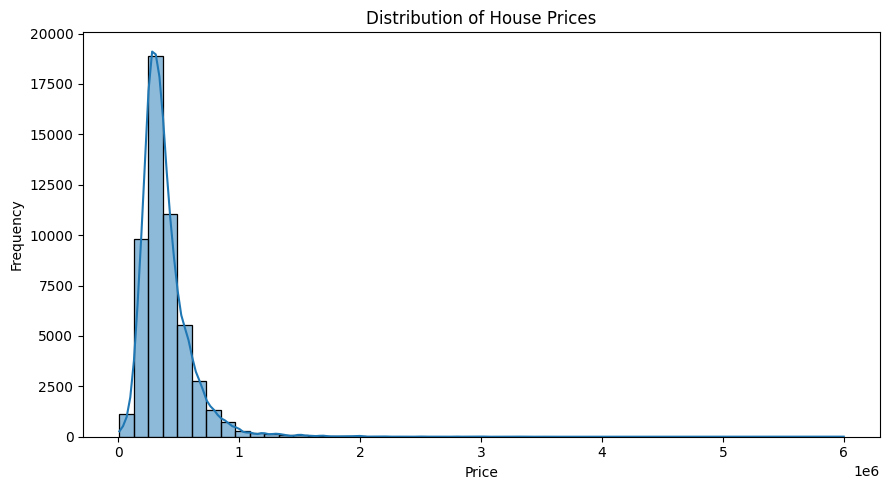

In [18]:
plt.figure(
    figsize=(9, 5)
)

sns.histplot(
    df_clean[TARGET],
    bins=50,
    kde=True
)

plt.title(
    "Distribution of House Prices"
)

plt.xlabel(
    "Price"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

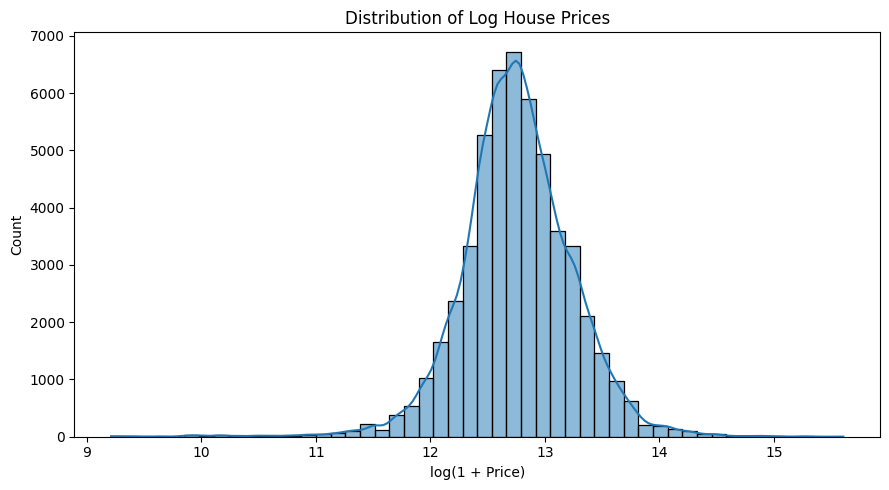

In [19]:
plt.figure(
    figsize=(9, 5)
)

sns.histplot(
    np.log1p(
        df_clean[TARGET]
    ),
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Log House Prices"
)

plt.xlabel(
    "log(1 + Price)"
)

plt.tight_layout()

plt.show()

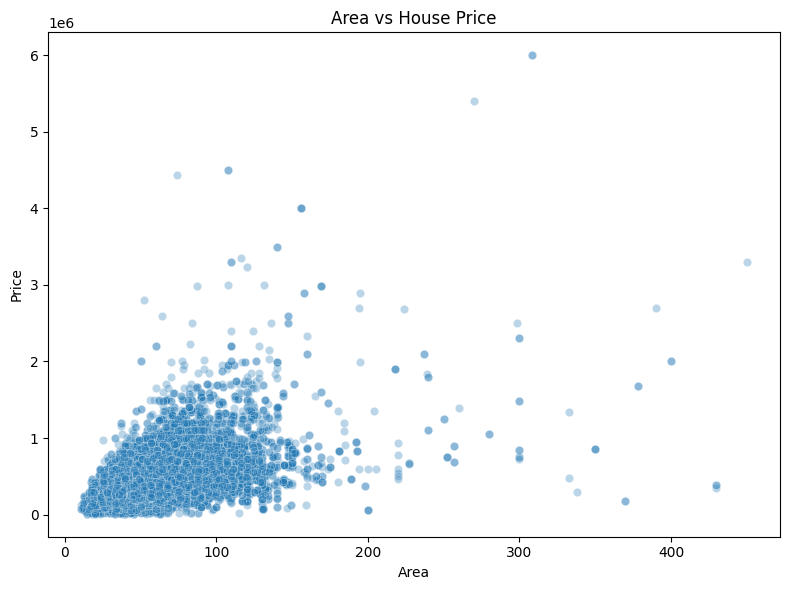

In [20]:
if "area" in df_clean.columns:

    plt.figure(
        figsize=(8, 6)
    )

    sns.scatterplot(
        data=df_clean,
        x="area",
        y=TARGET,
        alpha=0.3
    )

    plt.title(
        "Area vs House Price"
    )

    plt.xlabel(
        "Area"
    )

    plt.ylabel(
        "Price"
    )

    plt.tight_layout()

    plt.show()

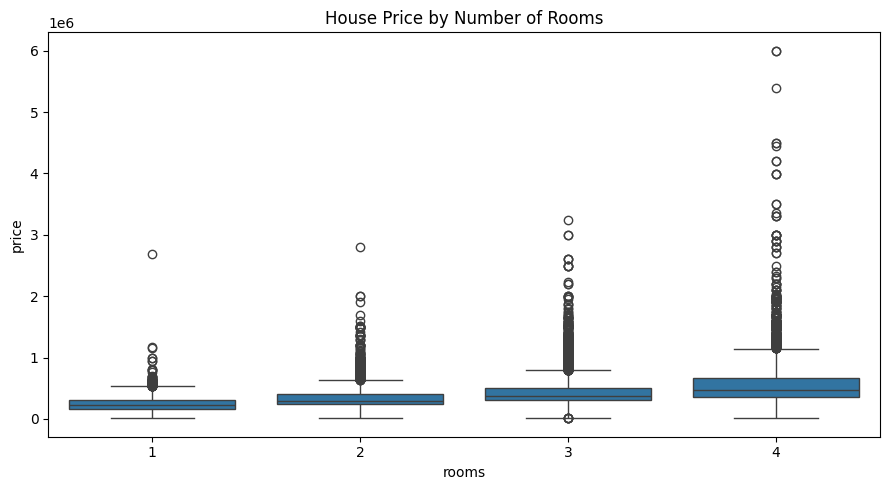

In [21]:
if "rooms" in df_clean.columns:

    plt.figure(
        figsize=(9, 5)
    )

    sns.boxplot(
        data=df_clean,
        x="rooms",
        y=TARGET
    )

    plt.title(
        "House Price by Number of Rooms"
    )

    plt.tight_layout()

    plt.show()

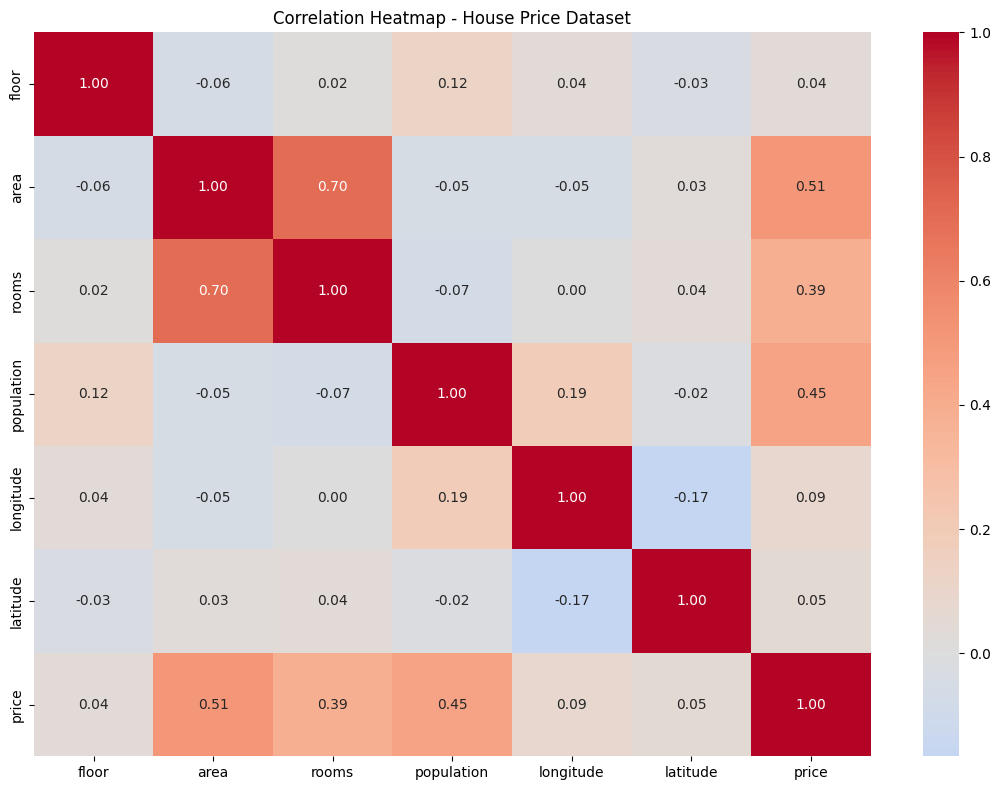

,Correlation_with_Price
area,0.512
population,0.452
rooms,0.386
longitude,0.088
latitude,0.053
floor,0.037


In [22]:
# Chỉ correlation trên các feature model thực sự được phép sử dụng

eda_numeric = pd.concat(
    [
        X.select_dtypes(
            include="number"
        ),
        y.rename(TARGET)
    ],
    axis=1
)


numeric_corr = (
    eda_numeric
    .corr()
)


plt.figure(
    figsize=(11, 8)
)

sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap - House Price Dataset"
)

plt.tight_layout()
plt.show()


target_corr = (
    numeric_corr[TARGET]
    .drop(TARGET)
    .sort_values(
        ascending=False
    )
)


display(
    target_corr
    .to_frame(
        "Correlation_with_Price"
    )
    .round(3)
)

## 9. Chia tập train, validation và test

Dữ liệu sạch được chia độc lập theo tỷ lệ 70% train, 15% validation và 15% test. Tập test được giữ nguyên cho đến khi đã chọn xong mô hình cuối.

In [23]:
X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE
    )
)


X_val, X_test, y_val, y_test = (
    train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_STATE
    )
)


split_table = pd.DataFrame({
    "Set": [
        "Train",
        "Validation",
        "Test"
    ],

    "Rows": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],

    "Percent": [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100
    ]
})


display(
    split_table.round(2)
)

,Set,Rows,Percent
0,Train,36502,70.0
1,Validation,7822,15.0
2,Test,7822,15.0


## 10. Pipeline tiền xử lý

Giá trị số thiếu được điền bằng trung vị của train rồi chuẩn hóa. Giá trị phân loại thiếu được điền bằng mode của train và one-hot encoding có hỗ trợ category chưa từng gặp.

In [24]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numerical_features
    ),

    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])


print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['floor', 'area', 'rooms', 'population',
                                  'longitude', 'latitude']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['offer_type', 'offer_type_of_building',
                                  'market', 'city_name', 'voivodeship',
                                  'month'])])


## 11. Mô hình cơ sở

Dummy Regressor dự đoán giá trung bình được dùng làm mốc tối thiểu mà các mô hình hồi quy phải vượt qua.

In [25]:
baseline = Pipeline([
    (
        "preprocessor",
        clone(
            preprocessor
        )
    ),

    (
        "model",
        DummyRegressor(
            strategy="mean"
        )
    )
])


baseline.fit(
    X_train,
    y_train
)


baseline_pred = (
    baseline
    .predict(
        X_val
    )
)


baseline_mse = (
    mean_squared_error(
        y_val,
        baseline_pred
    )
)


baseline_result = pd.DataFrame([{
    "Model":
        "Dummy Baseline",

    "MAE":
        mean_absolute_error(
            y_val,
            baseline_pred
        ),

    "MSE":
        baseline_mse,

    "RMSE":
        np.sqrt(
            baseline_mse
        ),

    "R2":
        r2_score(
            y_val,
            baseline_pred
        )
}])


display(
    baseline_result.round(2)
)

,Model,MAE,MSE,RMSE,R2
0,Dummy Baseline,142971.08,4.614903e+10,214823.25,-0.0


## 12. Xây dựng mô hình

Năm thuật toán hồi quy được huấn luyện với cùng tiền xử lý và cách chia dữ liệu. Random Forest được giới hạn độ phức tạp để giảm overfitting, thời gian huấn luyện và kích thước model.

In [26]:
models = {

    "Linear Regression":
        LinearRegression(),


    "Ridge Regression":
        Ridge(
            alpha=1.0
        ),


    "Decision Tree":
        DecisionTreeRegressor(
            random_state=RANDOM_STATE
        ),


    # Random Forest được giới hạn
    # để giảm kích thước model
    # và thời gian deployment
    "Random Forest":
        RandomForestRegressor(

            n_estimators=80,

            max_depth=20,

            min_samples_leaf=2,

            max_features=0.8,

            random_state=RANDOM_STATE,

            n_jobs=-1
        ),


    "Gradient Boosting":
        GradientBoostingRegressor(

            n_estimators=100,

            learning_rate=0.05,

            random_state=RANDOM_STATE
        )
}


print(
    "Number of models:",
    len(models)
)

Number of models: 5


In [27]:
results = []

trained_models = {}


for name, estimator in models.items():

    print(
        f"Training {name}..."
    )


    pipeline = Pipeline([
        (
            "preprocessor",
            clone(
                preprocessor
            )
        ),

        (
            "model",
            clone(
                estimator
            )
        )
    ])


    start = time.time()


    pipeline.fit(
        X_train,
        y_train
    )


    training_time = (
        time.time()
        - start
    )


    pred = (
        pipeline
        .predict(
            X_val
        )
    )


    mse = (
        mean_squared_error(
            y_val,
            pred
        )
    )


    results.append({

        "Model":
            name,

        "MAE":
            mean_absolute_error(
                y_val,
                pred
            ),

        "MSE":
            mse,

        "RMSE":
            np.sqrt(
                mse
            ),

        "R2":
            r2_score(
                y_val,
                pred
            ),

        "Training_Time_s":
            training_time
    })


    trained_models[
        name
    ] = pipeline


    print(
        f"Done: {training_time:.2f}s\n"
    )


results_df = pd.DataFrame(
    results
)


results_df = (
    results_df
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)


display(
    results_df.round(2)
)

Training Linear Regression...
Done: 0.48s

Training Ridge Regression...
Done: 0.18s

Training Decision Tree...
Done: 4.96s

Training Random Forest...
Done: 7.74s

Training Gradient Boosting...
Done: 4.87s



,Model,MAE,MSE,RMSE,R2,Training_Time_s
0,Random Forest,53116.78,1.002441e+10,100121.97,0.78,7.74
1,Decision Tree,47734.75,1.373909e+10,117213.88,0.70,4.96
2,Gradient Boosting,72537.58,1.479860e+10,121649.50,0.68,4.87
3,Linear Regression,70163.71,1.601388e+10,126545.95,0.65,0.48
4,Ridge Regression,70117.17,1.603639e+10,126634.87,0.65,0.18


## 13. Biểu diễn số cuối cùng

Phần này minh họa cách một tin đăng thô được chuyển thành vector số sau encoding và cho biết kích thước ma trận đầu vào cuối cùng của mô hình.

In [28]:
example_pipeline = (
    trained_models[
        "Linear Regression"
    ]
)


fitted_preprocessor = (
    example_pipeline
    .named_steps[
        "preprocessor"
    ]
)


raw_sample = (
    X_train.iloc[[0]]
)


transformed_sample = (
    fitted_preprocessor
    .transform(
        raw_sample
    )
)


X_train_transformed = (
    fitted_preprocessor
    .transform(
        X_train
    )
)


feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


print(
    "Raw sample shape:",
    raw_sample.shape
)

print(
    "Transformed sample shape:",
    transformed_sample.shape
)

print(
    "Raw training matrix shape:",
    X_train.shape
)

print(
    "Final model-input shape:",
    X_train_transformed.shape
)

print(
    "Final feature dimension:",
    len(
        feature_names
    )
)


print(
    "\nFirst 30 transformed features:"
)

print(
    feature_names[:30]
)

Raw sample shape: (1, 12)
Transformed sample shape: (1, 633)
Raw training matrix shape: (36502, 12)
Final model-input shape: (36502, 633)
Final feature dimension: 633

First 30 transformed features:
['num__floor' 'num__area' 'num__rooms' 'num__population' 'num__longitude'
 'num__latitude' 'cat__offer_type_Estate Agency' 'cat__offer_type_Private'
 'cat__offer_type_of_building_Apartment Building'
 'cat__offer_type_of_building_Housing Block'
 'cat__offer_type_of_building_Loft' 'cat__offer_type_of_building_Other'
 'cat__offer_type_of_building_Tenement' 'cat__market_aftermarket'
 'cat__market_primary' 'cat__city_name_Aleksandrów Kujawski'
 'cat__city_name_Aleksandrów Łódzki' 'cat__city_name_Alwernia'
 'cat__city_name_Andrychów' 'cat__city_name_Augustów'
 'cat__city_name_Babimost' 'cat__city_name_Barcin'
 'cat__city_name_Barczewo' 'cat__city_name_Barlinek'
 'cat__city_name_Bartoszyce' 'cat__city_name_Barwice'
 'cat__city_name_Bełchatów' 'cat__city_name_Bełżyce'
 'cat__city_name_Biała Piska' 

In [29]:
print(
    "===== RAW HOUSE RECORD ====="
)

display(
    raw_sample
)


print(
    "\n===== TRANSFORMED NUMERICAL VECTOR ====="
)


if hasattr(
    transformed_sample,
    "toarray"
):

    transformed_vector = (
        transformed_sample
        .toarray()[0]
    )

else:

    transformed_vector = (
        np.asarray(
            transformed_sample
        )[0]
    )


print(
    transformed_vector[:50]
)

print(
    "\nVector dimension:",
    len(
        transformed_vector
    )
)

===== RAW HOUSE RECORD =====


,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,population,longitude,latitude
43838,Private,7.0,49.0,2,Housing Block,aftermarket,Włocławek,Kuyavia-Pomerania,March,114885,19.072063,52.660554



===== TRANSFORMED NUMERICAL VECTOR =====
[ 2.14843888 -0.25372058 -0.60646647 -0.45359299 -0.04902699  0.63441197
  0.          1.          0.          1.          0.          0.
  0.          1.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]

Vector dimension: 633


## 14. So sánh trên tập validation

Các mô hình được so sánh bằng MAE, MSE, RMSE, R-squared và thời gian huấn luyện. RMSE dùng để xếp hạng vì phạt mạnh lỗi giá lớn, còn MAE thể hiện sai số trung bình trực tiếp theo PLN.

,Model,MAE,MSE,RMSE,R2,Training_Time_s
0,Random Forest,53116.78,1.002441e+10,100121.97,0.78,7.74
1,Decision Tree,47734.75,1.373909e+10,117213.88,0.70,4.96
2,Gradient Boosting,72537.58,1.479860e+10,121649.50,0.68,4.87
3,Linear Regression,70163.71,1.601388e+10,126545.95,0.65,0.48
4,Ridge Regression,70117.17,1.603639e+10,126634.87,0.65,0.18


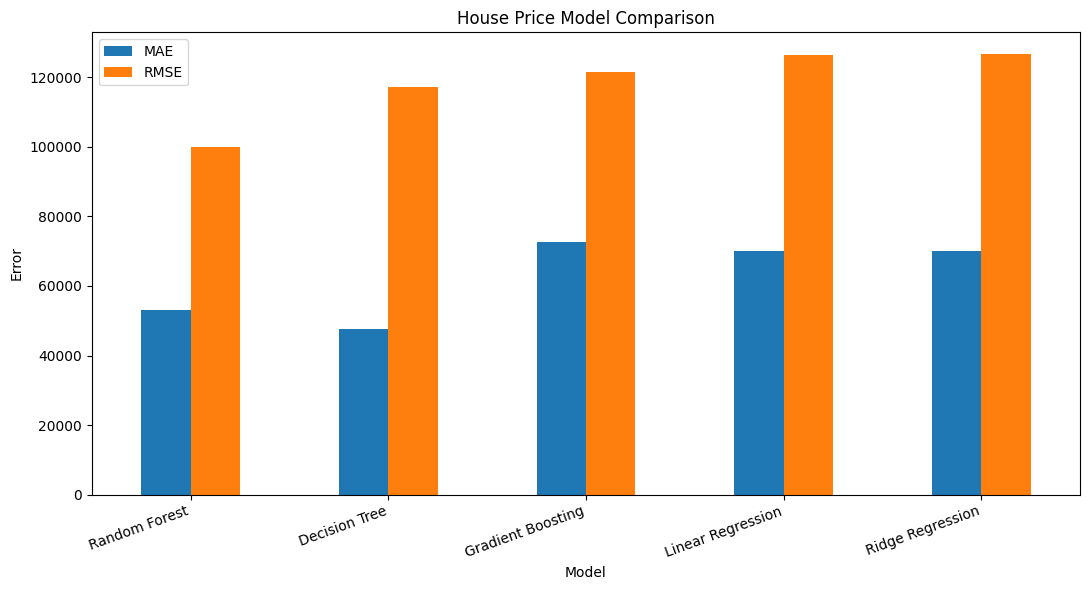

In [30]:
display(
    results_df.round(2)
)


comparison_plot = (
    results_df[
        [
            "Model",
            "MAE",
            "RMSE"
        ]
    ]
    .set_index(
        "Model"
    )
)


comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "House Price Model Comparison"
)

plt.ylabel(
    "Error"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()

## 15. Chọn mô hình cuối cùng

Mô hình cuối chỉ được chọn từ kết quả validation. Dữ liệu test không ảnh hưởng đến quyết định này.

In [31]:
best_name = (
    results_df
    .iloc[0][
        "Model"
    ]
)


best_model = (
    trained_models[
        best_name
    ]
)


print(
    "Selected model:",
    best_name
)


display(
    results_df.iloc[[0]]
    .round(2)
)

Selected model: Random Forest


,Model,MAE,MSE,RMSE,R2,Training_Time_s
0,Random Forest,53116.78,1.002441e+10,100121.97,0.78,7.74


## 16. Huấn luyện lại và đánh giá trên tập test

Pipeline được chọn được huấn luyện lại bằng train cộng validation rồi đánh giá một lần trên tập test chưa từng được sử dụng.

In [32]:
X_train_final = pd.concat(
    [
        X_train,
        X_val
    ],
    axis=0
)


y_train_final = pd.concat(
    [
        y_train,
        y_val
    ],
    axis=0
)


final_model = clone(
    best_model
)


final_model.fit(
    X_train_final,
    y_train_final
)


test_pred = (
    final_model
    .predict(
        X_test
    )
)


test_mse = (
    mean_squared_error(
        y_test,
        test_pred
    )
)


test_results = pd.DataFrame([{

    "Model":
        best_name,

    "MAE":
        mean_absolute_error(
            y_test,
            test_pred
        ),

    "MSE":
        test_mse,

    "RMSE":
        np.sqrt(
            test_mse
        ),

    "R2":
        r2_score(
            y_test,
            test_pred
        )

}])


display(
    test_results.round(2)
)

,Model,MAE,MSE,RMSE,R2
0,Random Forest,52768.35,1.002454e+10,100122.63,0.79


## 17. Phân tích residual và lỗi dự đoán

Biểu đồ residual, giá thực tế so với dự đoán và các dòng sai số lớn nhất cho biết mô hình đang dự đoán thiếu hoặc dự đoán thừa ở đâu.

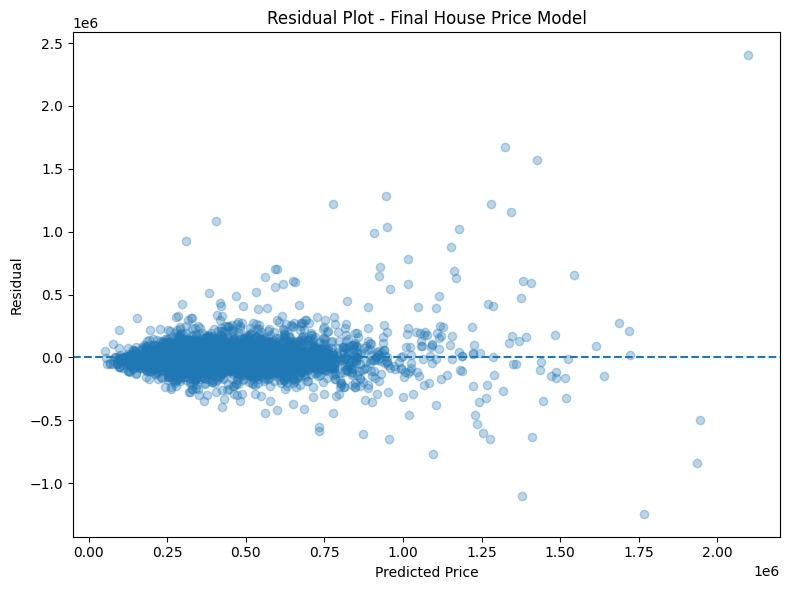

In [33]:
residuals = (
    y_test
    - test_pred
)


plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    test_pred,
    residuals,
    alpha=0.3
)


plt.axhline(
    y=0,
    linestyle="--"
)


plt.xlabel(
    "Predicted Price"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot - Final House Price Model"
)

plt.tight_layout()

plt.show()

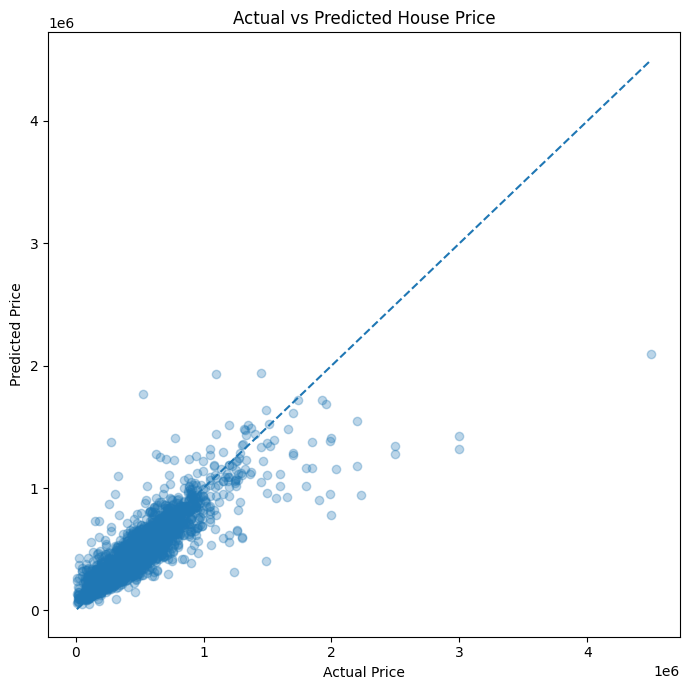

In [34]:
plt.figure(
    figsize=(7, 7)
)


plt.scatter(
    y_test,
    test_pred,
    alpha=0.3
)


minimum = min(
    y_test.min(),
    test_pred.min()
)

maximum = max(
    y_test.max(),
    test_pred.max()
)


plt.plot(
    [
        minimum,
        maximum
    ],
    [
        minimum,
        maximum
    ],
    linestyle="--"
)


plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted House Price"
)

plt.tight_layout()

plt.show()

In [35]:
error_df = X_test.copy()

error_df[
    "Actual_Price"
] = y_test.values

error_df[
    "Predicted_Price"
] = test_pred

error_df[
    "Absolute_Error"
] = np.abs(
    error_df["Actual_Price"]
    -
    error_df["Predicted_Price"]
)


display(
    error_df
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,population,longitude,latitude,Actual_Price,Predicted_Price,Absolute_Error
40538,Estate Agency,4.0,108.00,4,Apartment Building,aftermarket,Gdańsk,Pomerania,February,461935,18.654023,54.348291,4500000.0,2.097007e+06,2.402993e+06
59410,Estate Agency,1.0,108.00,3,Tenement,aftermarket,Kraków,Lesser Poland,March,762508,19.936856,50.061947,3000000.0,1.323038e+06,1.676962e+06
62258,Estate Agency,NaN,NaN,4,NaN,aftermarket,Warszawa,Masovia,March,1744351,21.006725,52.231958,2999000.0,1.427841e+06,1.571159e+06
61774,Estate Agency,4.0,82.47,3,Apartment Building,aftermarket,Świnoujście,West Pomerania,March,41371,14.251070,53.909748,2230000.0,9.444964e+05,1.285504e+06
18808,Estate Agency,NaN,NaN,4,NaN,aftermarket,Kraków,Lesser Poland,January,762508,19.936856,50.061947,525000.0,1.767874e+06,1.242874e+06
62752,Estate Agency,0.0,298.35,4,Other,aftermarket,Kołobrzeg,West Pomerania,March,44980,15.576421,54.175961,2500000.0,1.278672e+06,1.221328e+06
23195,Private,0.0,50.00,2,Tenement,aftermarket,Kraków,Lesser Poland,February,762508,19.936856,50.061947,2000000.0,7.787243e+05,1.221276e+06
59464,Private,1.0,83.83,3,Apartment Building,aftermarket,Kraków,Lesser Poland,March,762508,19.936856,50.061947,2500000.0,1.343412e+06,1.156588e+06
9062,Private,1.0,53.00,4,Housing Block,aftermarket,Kalisz,Greater Poland,January,103997,18.089536,51.762475,275000.0,1.377118e+06,1.102118e+06
52435,Private,0.0,62.19,2,Apartment Building,primary,Giżycko,Warmia-Masuria,March,29947,21.771309,54.040092,1490000.0,4.044330e+05,1.085567e+06


## 18. Lưu mô hình

Tiền xử lý và Random Forest đã fit được lưu chung trong artifact có nén để khi triển khai vẫn dùng đúng các phép biến đổi lúc huấn luyện.

In [36]:
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_PATH = (
    MODEL_DIR
    /
    "house_price_pipeline.joblib"
)


artifact = {

    "pipeline":
        final_model,

    "model_name":
        best_name,

    "raw_feature_names":
        X.columns.tolist(),

    "numerical_features":
        numerical_features,

    "categorical_features":
        categorical_features,

    "target":
        TARGET,

    "random_state":
        RANDOM_STATE,

    "test_metrics":
        test_results
        .iloc[0]
        .to_dict()
}


# =========================
# Save compressed artifact
# =========================

joblib.dump(
    artifact,
    MODEL_PATH,
    compress=3
)


model_size_mb = (
    MODEL_PATH
    .stat()
    .st_size
    /
    (
        1024 ** 2
    )
)


print(
    "Saved model:",
    MODEL_PATH
)

print(
    "Model:",
    best_name
)

print(
    "Compressed model size:",
    round(
        model_size_mb,
        2
    ),
    "MB"
)

Saved model: D:\Assignment2\models\house_price_pipeline.joblib
Model: Random Forest
Compressed model size: 19.39 MB


## 19. Dự đoán cho căn nhà mới

Tin đăng mới sử dụng diện tích, số phòng và thành phố do người dùng cung cấp. Dân số, tọa độ và khu vực được lấy nhất quán từ dữ liệu train của thành phố đã chọn.

In [37]:
loaded_artifact = (
    joblib.load(
        MODEL_PATH
    )
)


loaded_model = (
    loaded_artifact[
        "pipeline"
    ]
)


# =========================
# USER INPUT
# =========================

selected_city = "Warszawa"

user_area = 80
user_rooms = 3


# =========================
# Find selected city
# from TRAINING DATA
# =========================

city_data = (
    X_train[
        X_train[
            "city_name"
        ]
        ==
        selected_city
    ]
)


if len(city_data) == 0:

    raise ValueError(
        f"City '{selected_city}' "
        "was not found in training data."
    )


print(
    "Selected city:",
    selected_city
)

print(
    "Training listings for city:",
    len(city_data)
)


# =========================
# Default numerical values
# =========================

new_house_data = {}


for col in numerical_features:

    new_house_data[
        col
    ] = (
        X_train[
            col
        ]
        .median()
    )


# =========================
# Default categorical values
# =========================

for col in categorical_features:

    mode_value = (
        X_train[
            col
        ]
        .dropna()
        .mode()
    )

    new_house_data[
        col
    ] = (
        mode_value.iloc[0]

        if len(
            mode_value
        ) > 0

        else np.nan
    )


# =========================
# Actual user information
# =========================

new_house_data[
    "city_name"
] = selected_city


new_house_data[
    "area"
] = user_area


new_house_data[
    "rooms"
] = user_rooms


# =========================
# City-dependent attributes
# =========================

for col in [

    "population",

    "longitude",

    "latitude"

]:

    if (
        col
        in new_house_data
    ):

        new_house_data[
            col
        ] = (
            city_data[
                col
            ]
            .median()
        )


# Correct voivodeship
if (
    "voivodeship"
    in new_house_data
):

    city_region = (
        city_data[
            "voivodeship"
        ]
        .dropna()
        .mode()
    )

    if len(
        city_region
    ) > 0:

        new_house_data[
            "voivodeship"
        ] = (
            city_region.iloc[0]
        )


# =========================
# Create final user row
# =========================

new_house = pd.DataFrame([
    new_house_data
])


new_house = (
    new_house[
        loaded_artifact[
            "raw_feature_names"
        ]
    ]
)


print(
    "\n===== NEW HOUSE USER INPUT ====="
)


display(
    new_house
)


# =========================
# Prediction
# =========================

predicted_price = float(

    loaded_model

    .predict(
        new_house
    )[0]
)


print(
    "Loaded model:",
    loaded_artifact[
        "model_name"
    ]
)


print(
    "Predicted house price:",
    round(
        predicted_price,
        2
    ),
    "PLN"
)

Selected city: Warszawa
Training listings for city: 2632

===== NEW HOUSE USER INPUT =====


,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,population,longitude,latitude
0,Private,2.0,80,3,Housing Block,aftermarket,Warszawa,Masovia,March,1744351.0,21.006725,52.231958


Loaded model: Random Forest
Predicted house price: 878274.32 PLN
